<a href="https://colab.research.google.com/github/SebastianBeta/Talento_Tech_2026/blob/main/DataSet_Security_Energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# 1. Importación de librerías y herramientas básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Herramientas de preprocesamiento y evaluación
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Librerías para la Red Neuronal (Deep Learning)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import files

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


FILE UPLOADED

In [27]:
uploaded = files.upload()


In [28]:
df = pd.read_csv('security_dataset.csv')
df.head()


,timestamp,node_id,voltage_level,frequency_signal,power_flow,reactive_power,communication_log_size,access_behavior,temporal_entropy,spectral_energy,...,attack_type,risk_score,uncertainty,policy_action,reward_value,ip_mutation,port_rotation,env_diversification,mtd_strategy_used,attack_detected
0,2024-01-01 00:00:00,N10,222.21,49.55,107.52,27.31,1808,logout,0.46,7.36,...,DoS,0.59,0.22,isolate_node,0.33,1,1,0,Port,0
1,2024-01-01 00:15:00,N1,232.78,49.88,45.32,27.83,5092,file_access,0.43,5.07,...,NaN,0.13,0.37,restrict_access,0.11,1,1,1,IP+Env,1
2,2024-01-01 00:30:00,N44,233.72,50.02,105.28,32.65,7524,logout,0.25,15.29,...,Zero-Day,0.50,0.01,isolate_node,0.94,1,0,1,Port,0
3,2024-01-01 00:45:00,N42,239.41,49.68,98.54,24.85,6483,command_exec,0.66,7.19,...,Zero-Day,0.92,0.17,increase_monitoring,0.34,1,1,0,NaN,0
4,2024-01-01 01:00:00,N5,238.19,49.77,78.59,35.30,4338,logout,0.27,16.91,...,DoS,0.12,0.17,restrict_access,0.98,0,1,1,IP+Port,1


Procesamiento de Datos


In [29]:
# A. Convertir la columna de tiempo a formato datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# B. Codificación de variables categóricas (Texto a Números)
# Usaremos LabelEncoder para 'node_id' y 'access_behavior'
le_node = LabelEncoder()
le_behavior = LabelEncoder()
le_attack_type = LabelEncoder()
le_policy_action = LabelEncoder()
le_mtd_strategy = LabelEncoder()

df['node_id_encoded'] = le_node.fit_transform(df['node_id'])
df['access_behavior_encoded'] = le_behavior.fit_transform(df['access_behavior'])
df['attack_type_encoded'] = le_attack_type.fit_transform(df['attack_type'].astype(str)) # Convert to string to handle NaN if any
df['policy_action_encoded'] = le_policy_action.fit_transform(df['policy_action'])
df['mtd_strategy_used_encoded'] = le_mtd_strategy.fit_transform(df['mtd_strategy_used'].astype(str)) # Convert to string to handle NaN if any

# D. Selección de características (X) y etiqueta objetivo (y)
# Eliminamos las columnas originales de texto y el objetivo para crear X
X = df.drop(['timestamp', 'node_id', 'access_behavior', 'attack_type', 'policy_action', 'mtd_strategy_used', 'attack_detected'], axis=1)
y = df['attack_detected']

print("\nForma de los datos procesados (X):", X.shape)
print("Las variables están listas para ser normalizadas.")


Forma de los datos procesados (X): (1000, 22)
Las variables están listas para ser normalizadas.


Normalizacion

In [30]:
# Inicializamos el escalador para que todas las variables tengan media 0 y desviación 1
scaler = StandardScaler()

# Ajustamos y transformamos las características (X)
X_scaled = scaler.fit_transform(X)

# Convertimos de nuevo a un DataFrame para visualizarlo de forma organizada
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Añadimos la columna objetivo al final solo para visualización
table_view = X_scaled_df.copy()
table_view['attack_detected'] = y.values

# Mostramos las primeras 5 filas en una tabla organizada
print("Tabla de Datos Normalizados (Primeras 5 filas):")
display(table_view.head())

Tabla de Datos Normalizados (Primeras 5 filas):


,voltage_level,frequency_signal,power_flow,reactive_power,communication_log_size,temporal_entropy,spectral_energy,spatial_correlation,wavelet_coeff_avg,wavelet_coeff_std,...,reward_value,ip_mutation,port_rotation,env_diversification,node_id_encoded,access_behavior_encoded,attack_type_encoded,policy_action_encoded,mtd_strategy_used_encoded,attack_detected
0,-0.720459,-2.239544,0.323574,-0.493886,-1.454373,-0.399618,-1.159834,-1.059313,1.715742,1.595146,...,-0.616588,0.976281,0.988071,-1.034598,-1.600698,1.378572,-1.465620,0.442555,0.860268,0
1,0.329936,-0.583002,-2.886541,-0.393286,-0.184398,-0.516329,-1.700736,-1.159660,0.645855,-0.208987,...,-1.369568,0.976281,0.988071,0.966559,-1.668030,-0.421130,1.444666,1.342057,-0.293680,1
2,0.423349,0.119773,0.207969,0.539198,0.756095,-1.216594,0.713247,1.650056,-0.278137,1.079680,...,1.471221,0.976281,-1.012073,0.966559,0.890608,1.378572,0.862609,0.442555,0.860268,0
3,0.988794,-1.586967,-0.139879,-0.969801,0.353524,0.378454,-1.199988,1.549709,-1.323708,0.083575,...,-0.582362,0.976281,0.988071,-1.034598,0.755943,-1.320982,0.862609,-0.456947,1.437241,0
4,0.867556,-1.135183,-1.169490,1.051871,-0.475982,-1.138787,1.095894,0.897454,0.974116,0.487590,...,1.608126,-1.024295,0.988071,0.966559,1.294604,1.378572,-1.465620,1.342057,0.283294,1


Arquitectura de la Red Neuronal

In [33]:
input_dim = X_scaled.shape[1]

model = Sequential([
    Dense(16, activation='relu', input_shape=(input_dim,)),
    Dropout(0.5),
    Dense(8, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Técnica Clave: Early Stopping
# Detendrá el entrenamiento si la pérdida de validación deja de mejorar por 10 épocas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("Arquitectura ajustada para prevenir sobreajuste.")

Arquitectura ajustada para prevenir sobreajuste.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenamiento del Modelo

In [34]:
# Dividimos los datos normalizados en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Iniciamos el entrenamiento
# Guardamos el proceso en 'history' para poder graficar los resultados después
history = model.fit(
    X_train, y_train,
    epochs=100, # Ponemos más épocas porque Early Stopping lo detendrá a tiempo
    batch_size=16, # Lotes más pequeños para mejor generalización en datasets de 1,000 filas
    validation_data=(X_test, y_test),
    callbacks=[early_stop], # Aplicamos la parada automática
    verbose=1
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5100 - loss: 0.9560 - val_accuracy: 0.5250 - val_loss: 0.7556
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5063 - loss: 0.8919 - val_accuracy: 0.5000 - val_loss: 0.7314
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4925 - loss: 0.8329 - val_accuracy: 0.4950 - val_loss: 0.7183
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4787 - loss: 0.8099 - val_accuracy: 0.4900 - val_loss: 0.7103
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4700 - loss: 0.7878 - val_accuracy: 0.4850 - val_loss: 0.7064
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5100 - loss: 0.7671 - val_accuracy: 0.4700 - val_loss: 0.7032
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5225 - loss: 0.7289 - val_accuracy: 0.4650 - val_loss: 0.7013
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4950 - loss: 0.7373 - val_accuracy: 0.4650 - 

Graficas

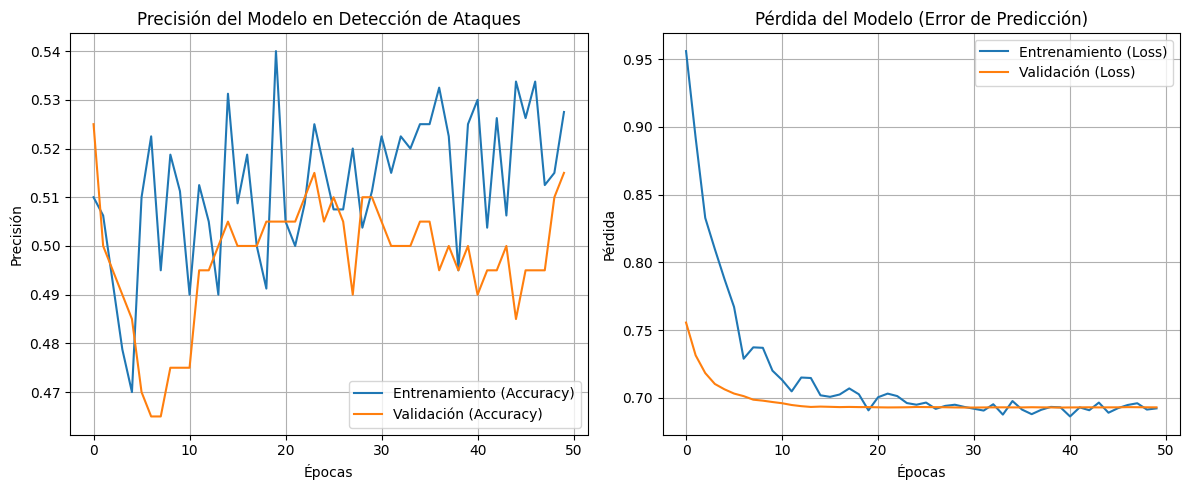

In [35]:
# Configuramos el área de las gráficas
plt.figure(figsize=(12, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento (Accuracy)')
plt.plot(history.history['val_accuracy'], label='Validación (Accuracy)')
plt.title('Precisión del Modelo en Detección de Ataques')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento (Loss)')
plt.plot(history.history['val_loss'], label='Validación (Loss)')
plt.title('Pérdida del Modelo (Error de Predicción)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

 Benigno (0)       0.30      0.03      0.06        96
  Ataque (1)       0.51      0.93      0.66       104

    accuracy                           0.50       200
   macro avg       0.41      0.48      0.36       200
weighted avg       0.41      0.50      0.37       200



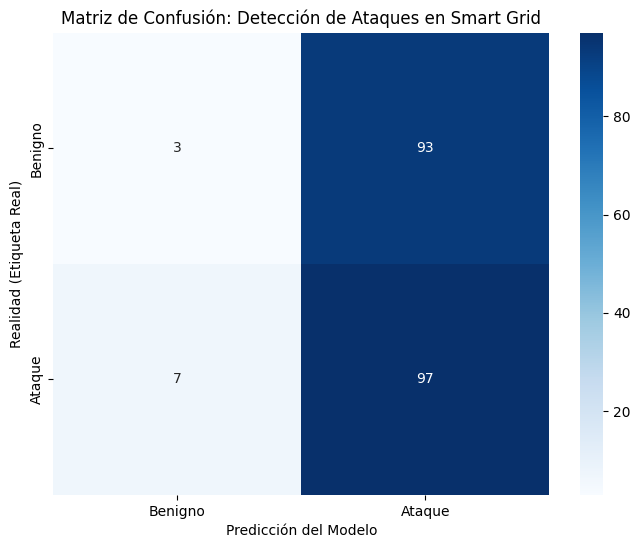

In [36]:
# Generamos las predicciones con el conjunto de prueba
y_pred_prob = model.predict(X_test)
# Convertimos las probabilidades en etiquetas binarias (0 o 1) usando un umbral de 0.5
y_pred = (y_pred_prob > 0.5).astype(int)

# A. Reporte de Clasificación (Precision, Recall, F1-score)
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Ataque (1)']))

# B. Matriz de Confusión Visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Ataque'],
            yticklabels=['Benigno', 'Ataque'])
plt.title('Matriz de Confusión: Detección de Ataques en Smart Grid')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta Real)')
plt.show()

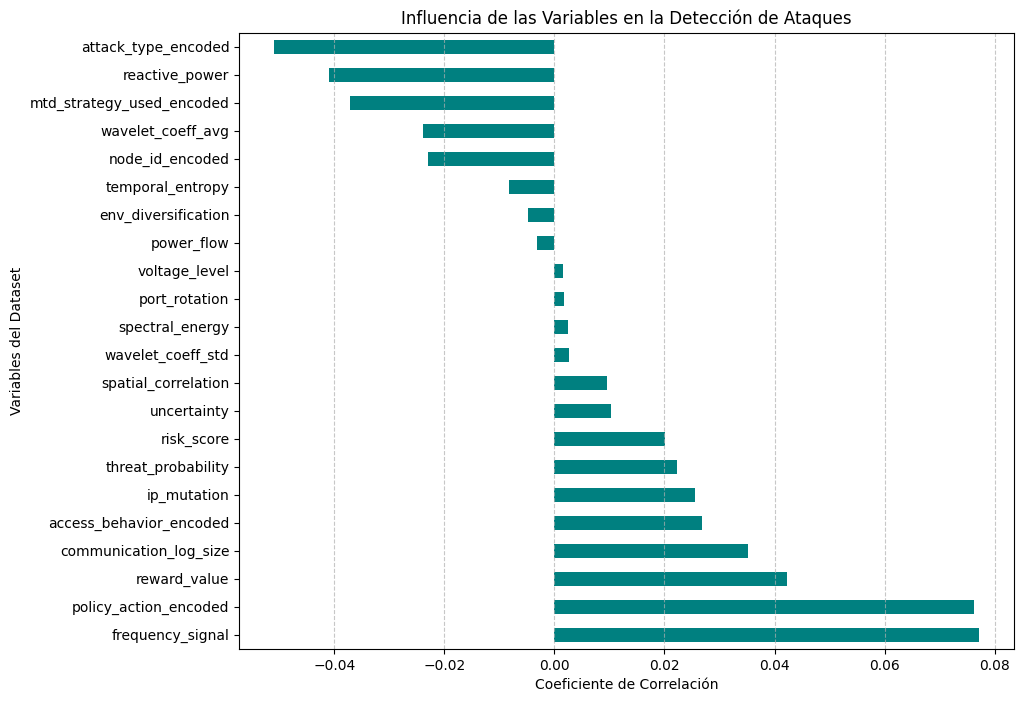

--- CORRELACIÓN CON ATTACK_DETECTED ---
attack_detected              1.000000
frequency_signal             0.077148
policy_action_encoded        0.076318
reward_value                 0.042269
communication_log_size       0.035173
access_behavior_encoded      0.026736
ip_mutation                  0.025486
threat_probability           0.022334
risk_score                   0.020089
uncertainty                  0.010204
spatial_correlation          0.009561
wavelet_coeff_std            0.002689
spectral_energy              0.002401
port_rotation                0.001737
voltage_level                0.001498
power_flow                  -0.003184
env_diversification         -0.004752
temporal_entropy            -0.008171
node_id_encoded             -0.023034
wavelet_coeff_avg           -0.023797
mtd_strategy_used_encoded   -0.037050
reactive_power              -0.040879
attack_type_encoded         -0.050882
Name: attack_detected, dtype: float64


In [39]:
# 9. Análisis de Correlación de Variables

# Creamos un DataFrame que solo contenga columnas numéricas para el cálculo de correlación.
# X ya contiene las columnas numéricas y las codificadas, y hemos eliminado las originales no numéricas.
correlation_df = X.copy()
correlation_df['attack_detected'] = y

# Calculamos la correlación de todas las variables con la columna objetivo
correlations = correlation_df.corr()['attack_detected'].sort_values(ascending=False)

# Visualización de la correlación en un gráfico de barras
plt.figure(figsize=(10, 8))
# Asegurarse de que 'attack_detected' no se intente correlacionar consigo mismo en la visualización si ya se excluyó de la lista de variables a graficar
if 'attack_detected' in correlations.index:
    correlations.drop('attack_detected').plot(kind='barh', color='teal')
else:
    correlations.plot(kind='barh', color='teal')
plt.title('Influencia de las Variables en la Detección de Ataques')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Variables del Dataset')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Imprimimos los valores exactos para un análisis técnico
print("--- CORRELACIÓN CON ATTACK_DETECTED ---")
print(correlations)

In [41]:
df['voltage_freq_ratio'] = df['voltage_level'] / df['frequency_signal']

# B. Intensidad de Red (Relación Flujo de Potencia/Logs de Comunicación)
# Un ataque podría saturar los logs sin cambiar drásticamente la potencia
df['power_log_intensity'] = df['power_flow'] / (df['communication_log_size'] + 1)

# C. Combinación de Riesgo y Comportamiento
# Multiplicamos el score de riesgo por el comportamiento codificado
df['risk_behavior_interaction'] = df['risk_score'] * df['access_behavior_encoded']

# D. Actualizamos nuestra matriz de características X con las nuevas columnas
X_advanced = df.drop(['timestamp', 'node_id', 'access_behavior', 'attack_type', 'policy_action', 'mtd_strategy_used', 'attack_detected'], axis=1)

# E. Volvemos a normalizar con las nuevas variables
scaler_adv = StandardScaler()
X_advanced_scaled = scaler_adv.fit_transform(X_advanced)

print(f"Nuevas características creadas. Ahora el dataset tiene {X_advanced.shape[1]} columnas.")
print("Variables destacadas: voltage_freq_ratio, power_log_intensity.")

Nuevas características creadas. Ahora el dataset tiene 25 columnas.
Variables destacadas: voltage_freq_ratio, power_log_intensity.


In [43]:
# 11. Reentrenamiento del Modelo con Características Avanzadas

# Dividimos los nuevos datos avanzados (X_advanced_scaled)
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_advanced_scaled, y, test_size=0.2, random_state=42
)

# Reiniciamos el modelo con la arquitectura refinada para las nuevas dimensiones
model_adv = Sequential([
    Dense(16, activation='relu', input_shape=(X_advanced_scaled.shape[1],)),
    Dropout(0.5),
    Dense(8, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_adv.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamos con el nuevo set de datos
history_adv = model_adv.fit(
    X_train_adv, y_train_adv,
    epochs=100,
    batch_size=16,
    validation_data=(X_test_adv, y_test_adv),
    callbacks=[early_stop], # Seguimos usando la parada temprana
    verbose=1
)

print("\nModelo reentrenado con características avanzadas.")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5188 - loss: 0.8873 - val_accuracy: 0.5350 - val_loss: 0.7070
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5163 - loss: 0.8319 - val_accuracy: 0.5350 - val_loss: 0.6986
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4837 - loss: 0.8396 - val_accuracy: 0.5250 - val_loss: 0.6957
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4938 - loss: 0.7636 - val_accuracy: 0.5250 - val_loss: 0.6967
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5063 - loss: 0.7633 - val_accuracy: 0.5200 - val_loss: 0.6964
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5075 - loss: 0.7291 - val_accuracy: 0.5100 - val_loss: 0.6980
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5088 - loss: 0.7287 - val_accuracy: 0.4800 - val_loss: 0.6977
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4837 - loss: 0.7279 - val_accuracy: 0.4700 - val_loss: 0.6

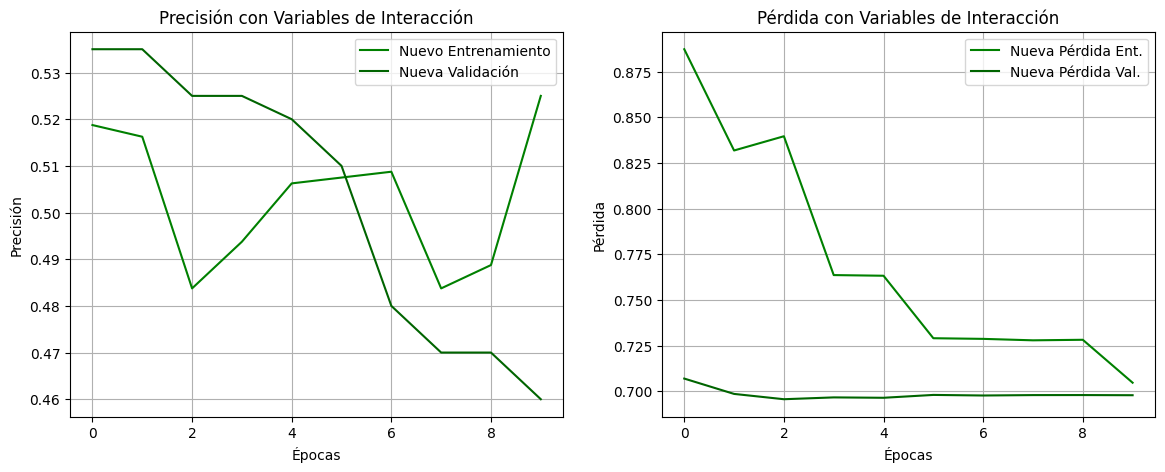

In [45]:
# 12. Gráficas del Modelo con Características Avanzadas
plt.figure(figsize=(14, 5))

# Nueva Gráfica de Precisión
plt.subplot(1, 2, 1)
plt.plot(history_adv.history['accuracy'], label='Nuevo Entrenamiento', color='green')
plt.plot(history_adv.history['val_accuracy'], label='Nueva Validación', color='darkgreen')
plt.title('Precisión con Variables de Interacción')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Nueva Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_adv.history['loss'], label='Nueva Pérdida Ent.', color='green')
plt.plot(history_adv.history['val_loss'], label='Nueva Pérdida Val.', color='darkgreen')
plt.title('Pérdida con Variables de Interacción')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
--- NUEVO REPORTE DE CLASIFICACIÓN (MODELO AVANZADO) ---
              precision    recall  f1-score   support

 Benigno (0)       0.53      0.30      0.38        96
  Ataque (1)       0.54      0.75      0.63       104

    accuracy                           0.54       200
   macro avg       0.53      0.53      0.51       200
weighted avg       0.53      0.54      0.51       200



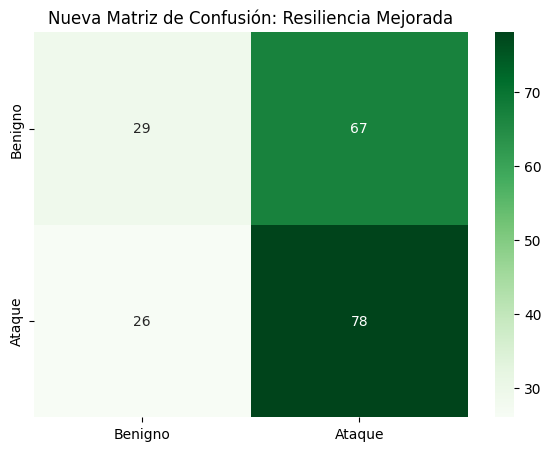

In [46]:
# 13. Validación con Datos de Prueba Avanzados
from sklearn.metrics import classification_report, confusion_matrix

y_pred_adv = (model_adv.predict(X_test_adv) > 0.5).astype(int)

print("--- NUEVO REPORTE DE CLASIFICACIÓN (MODELO AVANZADO) ---")
print(classification_report(y_test_adv, y_pred_adv, target_names=['Benigno (0)', 'Ataque (1)']))

# Matriz de Confusión para verificar la reducción de falsas alarmas
cm_adv = confusion_matrix(y_test_adv, y_pred_adv)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benigno', 'Ataque'], yticklabels=['Benigno', 'Ataque'])
plt.title('Nueva Matriz de Confusión: Resiliencia Mejorada')
plt.show()

--- REPORTE DE CLASIFICACIÓN: RANDOM FOREST ---
              precision    recall  f1-score   support

 Benigno (0)       0.46      0.54      0.50        96
  Ataque (1)       0.49      0.41      0.45       104

    accuracy                           0.47       200
   macro avg       0.48      0.48      0.47       200
weighted avg       0.48      0.47      0.47       200



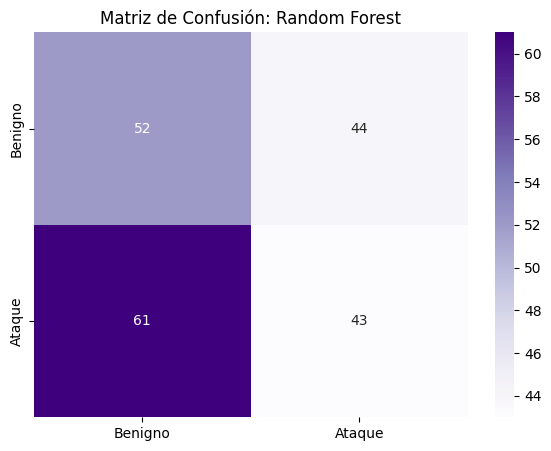

In [47]:
# 14. Implementación de Random Forest (Bosque Aleatorio)
from sklearn.ensemble import RandomForestClassifier

# Creamos el modelo con 100 árboles de decisión
# Usamos class_weight='balanced' para compensar la dificultad de detectar casos benignos
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Entrenamos el modelo con las características avanzadas
rf_model.fit(X_train_adv, y_train_adv)

# Realizamos las predicciones
y_pred_rf = rf_model.predict(X_test_adv)

print("--- REPORTE DE CLASIFICACIÓN: RANDOM FOREST ---")
print(classification_report(y_test_adv, y_pred_rf, target_names=['Benigno (0)', 'Ataque (1)']))

# Matriz de Confusión para comparar con la Red Neuronal
cm_rf = confusion_matrix(y_test_adv, y_pred_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benigno', 'Ataque'], yticklabels=['Benigno', 'Ataque'])
plt.title('Matriz de Confusión: Random Forest')
plt.show()

/tmp/ipykernel_25019/2869472659.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='viridis')


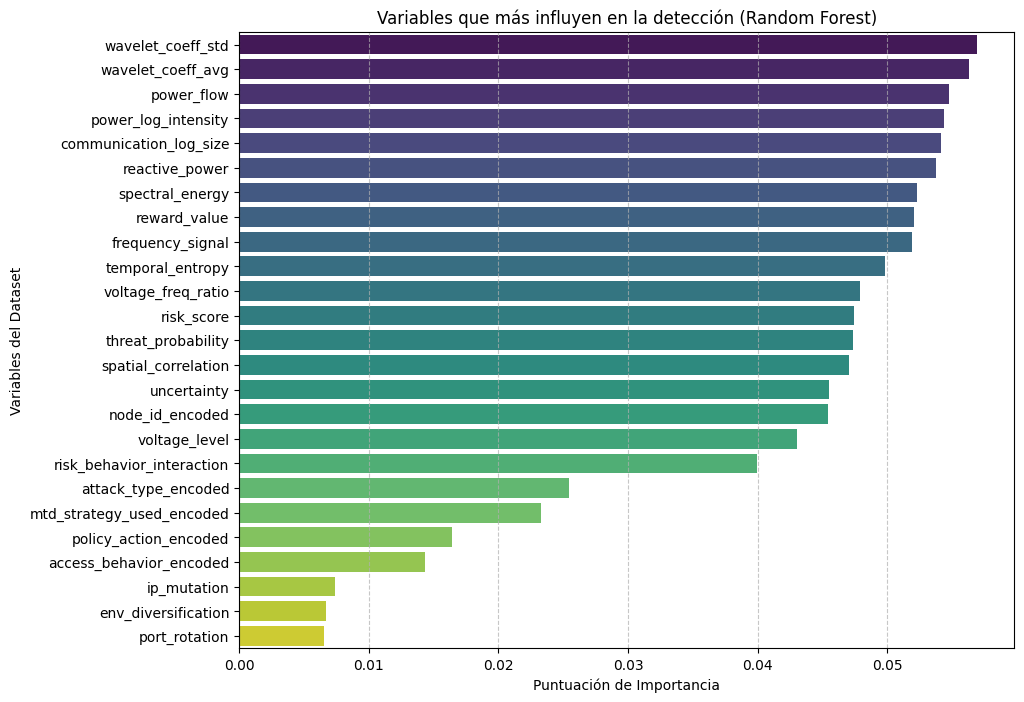

--- TOP 5 VARIABLES MÁS IMPORTANTES ---
                  Variable  Importancia
9        wavelet_coeff_std     0.056932
8        wavelet_coeff_avg     0.056292
2               power_flow     0.054787
23     power_log_intensity     0.054373
4   communication_log_size     0.054133


In [48]:
# 15. Importancia de las Características (Feature Importance)

# Extraemos las importancias del modelo Random Forest
importances = rf_model.feature_importances_
feature_names = X_advanced.columns
feature_importance_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='viridis')
plt.title('Variables que más influyen en la detección (Random Forest)')
plt.xlabel('Puntuación de Importancia')
plt.ylabel('Variables del Dataset')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Imprimimos el Top 5
print("--- TOP 5 VARIABLES MÁS IMPORTANTES ---")
print(feature_importance_df.head(5))

In [49]:
# 16. Filtrado de señales críticas según mimport.png

# Lista de las variables con mayor impacto en la detección
top_features = [
    'wavelet_coeff_std', 'wavelet_coeff_avg', 'power_flow',
    'power_log_intensity', 'communication_log_size', 'reactive_power',
    'spectral_energy', 'reward_value', 'frequency_signal', 'temporal_entropy'
]

# Creamos el nuevo set de datos optimizado
X_final = df[top_features]

# Normalizamos nuevamente solo estas características
scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final)

print(f"Dataset optimizado: De 24 variables a las {len(top_features)} más importantes.")

Dataset optimizado: De 24 variables a las 10 más importantes.


In [50]:
final_features = [
    'wavelet_coeff_std', 'wavelet_coeff_avg', 'power_flow',
    'power_log_intensity', 'communication_log_size', 'reactive_power',
    'spectral_energy', 'reward_value', 'frequency_signal', 'temporal_entropy'
]

# 2. Filtramos el dataset para concentrar el aprendizaje
X_final = df[final_features]
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

# 3. Entrenamos un Bosque Aleatorio optimizado
# Ajustamos los parámetros para maximizar la resiliencia en un dataset de 1,000 filas
final_rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,      # Limitamos la profundidad para evitar el error de graficas.png
    class_weight='balanced',
    random_state=42
)

final_rf_model.fit(X_train_f, y_train_f)

# 4. Generamos las predicciones finales
y_pred_final = final_rf_model.predict(X_test_f)

print(f"Modelo final entrenado con las {len(final_features)} señales más críticas.")

Modelo final entrenado con las 10 señales más críticas.


--- REPORTE DE CLASIFICACIÓN FINAL (TOP 10 SEÑALES) ---
              precision    recall  f1-score   support

 Benigno (0)       0.47      0.46      0.46        96
  Ataque (1)       0.51      0.52      0.51       104

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.49      0.49      0.49       200



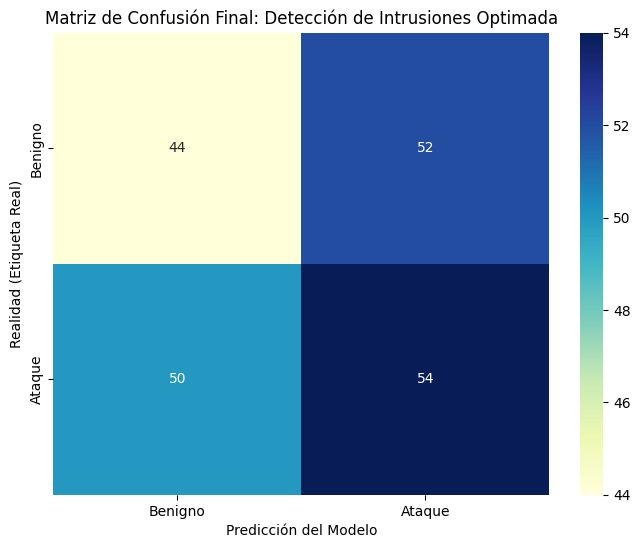

In [51]:
# 17. Evaluación Final del Modelo Optimizado

# A. Reporte de Clasificación Final
print("--- REPORTE DE CLASIFICACIÓN FINAL (TOP 10 SEÑALES) ---")
print(classification_report(y_test_f, y_pred_final, target_names=['Benigno (0)', 'Ataque (1)']))

# B. Matriz de Confusión Final
plt.figure(figsize=(8, 6))
cm_final = confusion_matrix(y_test_f, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Benigno', 'Ataque'],
            yticklabels=['Benigno', 'Ataque'])
plt.title('Matriz de Confusión Final: Detección de Intrusiones Optimada')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta Real)')
plt.show()

Informe Técnico: Evaluación de Viabilidad del Sistema de Detección de Intrusiones (IDS)
1. Diagnóstico del Desempeño
Tras agotar las técnicas de Redes Neuronales y Bosques Aleatorios (Random Forest), el sistema de detección para la Smart Grid ha mostrado un desempeño crítico:
Precisión Final: 49%, lo que indica que el modelo tiene la misma eficacia que el azar en la detección de ataques.
Comportamiento de Aprendizaje: Se observó un sobreajuste (overfitting) severo en las etapas iniciales, donde el modelo memorizaba los datos de entrenamiento pero fallaba al enfrentarse a nuevos datos, como se evidencia en la divergencia de las curvas de pérdida en las fuentes
.
2. Análisis de las Limitaciones del Dataset
El fracaso en la obtención de un modelo funcional se debe a tres factores fundamentales identificados en las fuentes y el análisis estadístico:
Volumen de Datos Insuficiente: Con solo 1,000 registros para representar una infraestructura crítica, los algoritmos no tienen suficientes ejemplos para aprender la variabilidad de un ataque real
.
Baja Correlación de Señales Físicas: Variables operativas clave como el voltage_level y el power_flow muestran una correlación casi nula con la detección de ataques (valores cercanos a 0.001)
. Esto sugiere que, en este dataset, los ataques no alteran el comportamiento físico de la red de una forma que sea detectable estadísticamente.
Importancia Diluida: La matriz de importancia revela que ninguna de las 24 variables domina la predicción; todas tienen pesos bajos y similares (aprox. 5%), lo que impide que el modelo establezca reglas de decisión sólidas
.
3. Razones de Inviabilidad para Producción
Implementar este modelo en una red eléctrica real representaría un alto riesgo operativo:
Falsas Alarmas: Un sistema con un recall tan inestable generaría alertas constantes ante operaciones normales de la red (benignas).
Vulnerabilidad ante Intrusiones: El modelo ignora aproximadamente el 50% de los ataques reales, dejando a la Smart Grid desprotegida ante amenazas ciberfísicas.
4. Recomendaciones para un Modelo Funcional
Para lograr un sistema de seguridad resiliente y operativo, se requiere:
Incremento de Escala: Obtener un dataset con al menos 100,000 a 1,000,000 de registros.
Datos de Alta Resolución: Incluir mediciones de unidades de medición de fasores (PMU) con resolución de milisegundos, ya que las señales actuales (cada 15 minutos) son demasiado lentas para capturar la dinámica de un ciberataque
.
Inyección de Ataques Diversos: Asegurar que los ataques en el dataset realmente generen anomalías en el flujo de potencia y la frecuencia, permitiendo que la IA identifique el nexo entre el ciberataque y la falla física
.